# ⚖️ Tribunal de Incoherencias — LangGraph `create_react_agent`

Versión con **LangGraph** usando `create_react_agent` para cada agente y `StateGraph` como orquestador del grafo.

| Agente | Rol | Tools disponibles |
|---|---|---|
| 🙏 **El Sacerdote** | Ultraconservador, dogmático y de muy mal genio | `analizar_moral`, `citar_escritura` |
| 🎭 **El Crítico de Arte** | Siempre invitado a Cannes, refinado y elitista | `analizar_estetica`, `referencias_culturales` |
| 🔥 **El Crítico del Crítico** | Iconoclasta que deconstruye a los anteriores | `refutar_argumento`, `perspectiva_popular` |
| ⚖️ **El Juez** | Escucha los 3 y dicta veredicto JSON | `puntuar_argumento`, `emitir_veredicto` |

### 🗺️ StateGraph de LangGraph

```
  START
    │
    ▼
 [sacerdote]  ←── create_react_agent con tools propias
    │
    ▼
  [critico]   ←── create_react_agent con tools propias  
    │
    ▼
[iconoclasta] ←── create_react_agent (lee state con sac+crit)
    │
    ▼
  [juez]      ←── create_react_agent → emite veredicto JSON
    │
    ▼
   END
```

## 📦 Instalación

In [1]:
# Instalación exacta requerida
!pip install langchain-classic langchain-openai langchain-core langgraph langchain
!pip install networkx matplotlib --quiet
print('✅ Todas las dependencias instaladas.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.2 MB/s eta 0:00:00
✅ Todas las dependencias instaladas.


## 🔑 Imports y configuración

In [2]:
from google.colab import userdata

OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
print('OPENAI_API_KEY cargada correctamente.')

OPENAI_API_KEY cargada correctamente.


In [4]:
import getpass, json, textwrap
from typing import TypedDict, Annotated
import operator

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# LangChain core
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

# LangGraph
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import create_react_agent


# LLM base para los 3 agentes deliberantes
llm = ChatOpenAI(
    model='gpt-4o',
    temperature=0.85,
    max_tokens=700,
    openai_api_key=OPENAI_API_KEY
)

# LLM dedicado para el Juez (más determinista, más tokens para JSON)
llm_juez = ChatOpenAI(
    model='gpt-4o',
    temperature=0.2,
    max_tokens=1200,
    openai_api_key=OPENAI_API_KEY
)


#json_parser = JsonOutputParser()
print('✅ LLMs inicializados.')
print(f'   llm      → gpt-4o  temp=0.85  max_tokens=700')
print(f'   llm_juez → gpt-4o  temp=0.20  max_tokens=1200')

✅ LLMs inicializados.
   llm      → gpt-4o  temp=0.85  max_tokens=700
   llm_juez → gpt-4o  temp=0.20  max_tokens=1200


## 🧰 Tools de cada agente

Cada agente tiene tools específicas decoradas con `@tool`.
Los `create_react_agent` las invocan autónomamente en su ciclo ReAct.

In [5]:
# ════════════════════════════════════════════════════════
#  🙏 TOOLS DEL SACERDOTE
# ════════════════════════════════════════════════════════

@tool
def analizar_moral(aspecto: str) -> str:
    """Analiza si un aspecto de la obra viola principios morales o religiosos.
    Arg: aspecto — descripción del elemento a evaluar moralmente."""
    return (
        f"Evaluación moral de '{aspecto}': Este elemento debe ser juzgado "
        "bajo los principios de la ley divina y la moral natural. "
        "El análisis debe señalar si corrompe las almas, contradice la fe "
        "o promueve el relativismo moral."
    )

@tool
def citar_escritura(tema: str) -> str:
    """Invoca autoridad escritural o doctrinaria para reforzar un argumento moral.
    Arg: tema — el tema moral sobre el cual buscar autoridad doctrinal."""
    citas = {
        'violencia': 'No matarás. (Éxodo 20:13) — La violencia gratuita ofende a Dios.',
        'lujuria':   'Todo el que mira a una mujer con deseo ya adulteró. (Mateo 5:28)',
        'soberbia':  'Dios resiste a los soberbios. (Santiago 4:6)',
        'mentira':   'El diablo es el padre de la mentira. (Juan 8:44)',
        'default':   'Examínalo todo; retén lo bueno. (1 Tesalonicenses 5:21)',
    }
    for k, v in citas.items():
        if k in tema.lower():
            return v
    return citas['default']


# ════════════════════════════════════════════════════════
#  🎭 TOOLS DEL CRÍTICO DE ARTE
# ════════════════════════════════════════════════════════

@tool
def analizar_estetica(elemento: str) -> str:
    """Evalúa un elemento narrativo o cinematográfico bajo criterios estéticos rigurosos.
    Arg: elemento — el recurso narrativo, visual o estructural a analizar."""
    return (
        f"Análisis estético de '{elemento}': Desde una perspectiva formalista, "
        "este elemento debe evaluarse en términos de coherencia intertextual, "
        "deuda con la tradición (nouvelle vague, realismo mágico, neorrealismo), "
        "y si su uso justifica o traiciona las expectativas del género."
    )

@tool
def referencias_culturales(concepto: str) -> str:
    """Recupera referencias a obras canónicas o autores para sustentar la crítica.
    Arg: concepto — el concepto o técnica a contextualizar con referencias."""
    refs = [
        f"Recuerda que Godard ya exploró '{concepto}' en 'À bout de souffle' (1960).",
        f"Borges advirtió sobre '{concepto}' en 'Ficciones' con mucho más rigor.",
        f"Tarkovsky habría resuelto '{concepto}' con una sola imagen, sin diálogo.",
        f"La escuela de Frankfurt analizó '{concepto}' como síntoma de la industria cultural.",
    ]
    import hashlib
    idx = int(hashlib.md5(concepto.encode()).hexdigest(), 16) % len(refs)
    return refs[idx]


# ════════════════════════════════════════════════════════
#  🔥 TOOLS DEL ICONOCLASTA
# ════════════════════════════════════════════════════════

@tool
def refutar_argumento(argumento: str) -> str:
    """Deconstruye y refuta un argumento del establishment crítico o religioso.
    Arg: argumento — el argumento elitista o moralista a demoler."""
    return (
        f"Refutación de: '{argumento[:80]}...': "
        "Este argumento es un ejemplo clásico de gatekeeping cultural. "
        "Ignora que la audiencia popular lee la obra de forma más honesta "
        "que cualquier crítico que solo habla con otros críticos. "
        "La incoherencia señalada es en realidad una característica, no un bug."
    )

@tool
def perspectiva_popular(obra: str) -> str:
    """Aporta la lectura popular y anti-elitista de una obra.
    Arg: obra — nombre de la obra a analizar desde la perspectiva popular."""
    return (
        f"Lectura popular de '{obra}': Las audiencias masivas entendieron "
        "instintivamente lo que los críticos académicos tardaron décadas en teorizar. "
        "La recepción popular es datos, no opinión. "
        "El 'vulgo' que el crítico desprecia tiene razón más veces de lo que admiten."
    )


# ════════════════════════════════════════════════════════
#  ⚖️ TOOLS DEL JUEZ
# ════════════════════════════════════════════════════════

@tool
def puntuar_argumento(agente: str, criterio: str, razon: str) -> str:
    """Registra la puntuación de un agente en un criterio específico.
    Args: agente — id del agente (sacerdote/critico/iconoclasta).
          criterio — solidez, coherencia o evidencia.
          razon — justificación del puntaje."""
    return f"Puntaje registrado: {agente} / {criterio} → justificación: {razon[:60]}"

@tool
def emitir_veredicto(ganador_id: str, fundamento: str, sentencia: str) -> str:
    """Formaliza el veredicto final del tribunal.
    Args: ganador_id — sacerdote, critico o iconoclasta.
          fundamento — razón jurídica del fallo.
          sentencia — frase solemne final."""
    return (
        f"VEREDICTO FORMAL — Ganador: {ganador_id}. "
        f"Fundamento: {fundamento[:80]}. "
        f"Sentencia: {sentencia[:60]}."
    )


print('✅ Tools definidas:')
print('   🙏 Sacerdote   → analizar_moral, citar_escritura')
print('   🎭 Crítico     → analizar_estetica, referencias_culturales')
print('   🔥 Iconoclasta → refutar_argumento, perspectiva_popular')
print('   ⚖️ Juez        → puntuar_argumento, emitir_veredicto')

✅ Tools definidas:
   🙏 Sacerdote   → analizar_moral, citar_escritura
   🎭 Crítico     → analizar_estetica, referencias_culturales
   🔥 Iconoclasta → refutar_argumento, perspectiva_popular
   ⚖️ Juez        → puntuar_argumento, emitir_veredicto


## 🤖 Creación de agentes con `create_react_agent`

Cada agente es un **ReAct loop** autónomo: razona, decide qué tool usar, la ejecuta, y repite hasta tener su argumento final.

In [6]:
# ── 🙏 AGENTE: El Sacerdote ───────────────────────────────────────────────
SYSTEM_SACERDOTE = """Eres un sacerdote ultraconservador, dogmático y de muy mal genio.
Analizas obras desde una perspectiva moral y religiosa estricta.
Te escandalizan las incoherencias éticas y la decadencia moral.
Tu tono es airado, indignado y sentencioso. Usas lenguaje arcaico cuando te exaltas.
DEBES usar tus tools para fundamentar tu análisis antes de responder.
Señala exactamente 3 incoherencias concretas. Máximo 250 palabras."""

react_sacerdote = create_react_agent(
    model=llm,
    tools=[analizar_moral, citar_escritura],
    prompt=SYSTEM_SACERDOTE,
)

# ── 🎭 AGENTE: El Crítico de Arte ─────────────────────────────────────────
SYSTEM_CRITICO = """Eres el crítico de arte más refinado y elitista del mundo, siempre invitado a Cannes.
Analizas obras con sofisticación aplastante. Ves incoherencias narrativas y estéticas que el vulgo ignora.
Tu tono es condescendiente y lleno de referencias culturales oscuras.
DEBES usar tus tools para enriquecer tus referencias antes de responder.
Señala exactamente 3 incoherencias concretas. Máximo 250 palabras."""

react_critico = create_react_agent(
    model=llm,
    tools=[analizar_estetica, referencias_culturales],
    prompt=SYSTEM_CRITICO,
)

# ── 🔥 AGENTE: El Iconoclasta ─────────────────────────────────────────────
SYSTEM_ICONOCLASTA = """Eres un crítico iconoclasta y provocador.
Tu misión es destruir los argumentos del crítico elitista y el sacerdote.
Eres irreverente y despiadado con el establishment cultural.
DEBES usar tus tools para refutar argumentos concretos de los otros agentes.
Debes: (1) refutar al menos 2 argumentos de los otros, (2) señalar 2 incoherencias propias.
Máximo 280 palabras."""

react_iconoclasta = create_react_agent(
    model=llm,
    tools=[refutar_argumento, perspectiva_popular],
    prompt=SYSTEM_ICONOCLASTA,
)

# ── ⚖️ AGENTE: El Juez ────────────────────────────────────────────────────
JSON_SCHEMA = """{
  "veredicto": {
    "ganador": "nombre del agente ganador",
    "ganador_id": "sacerdote|critico|iconoclasta",
    "puntajes": {
      "sacerdote":   {"solidez": 7, "coherencia": 8, "evidencia": 6},
      "critico":     {"solidez": 7, "coherencia": 8, "evidencia": 6},
      "iconoclasta": {"solidez": 7, "coherencia": 8, "evidencia": 6}
    },
    "fundamento_legal": "párrafo explicando el fallo, máx 100 palabras",
    "fallos_de_los_perdedores": {
      "perdedor1": "por qué perdió",
      "perdedor2": "por qué perdió"
    },
    "incoherencias_mas_solidas": ["incoherencia 1", "incoherencia 2", "incoherencia 3"],
    "sentencia": "frase solemne final, máx 30 palabras"
  }
}"""

SYSTEM_JUEZ = f"""Eres el mejor juez del país.
Tu ÚNICA función es evaluar la calidad argumentativa de los tres testigos.
NO emites opinión personal sobre la obra.
DEBES usar tus tools para registrar puntajes antes de emitir el veredicto.
Tu respuesta final DEBE ser ÚNICAMENTE un JSON válido con esta estructura exacta:
{JSON_SCHEMA}"""

react_juez = create_react_agent(
    model=llm_juez,
    tools=[puntuar_argumento, emitir_veredicto],
    prompt=SYSTEM_JUEZ,
)

print('✅ Agentes ReAct creados con create_react_agent:')
print('   react_sacerdote   — tools: analizar_moral, citar_escritura')
print('   react_critico     — tools: analizar_estetica, referencias_culturales')
print('   react_iconoclasta — tools: refutar_argumento, perspectiva_popular')
print('   react_juez        — tools: puntuar_argumento, emitir_veredicto')

✅ Agentes ReAct creados con create_react_agent:
   react_sacerdote   — tools: analizar_moral, citar_escritura
   react_critico     — tools: analizar_estetica, referencias_culturales
   react_iconoclasta — tools: refutar_argumento, perspectiva_popular
   react_juez        — tools: puntuar_argumento, emitir_veredicto


/tmp/ipykernel_818/1436449848.py:9: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_sacerdote = create_react_agent(
/tmp/ipykernel_818/1436449848.py:22: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_critico = create_react_agent(
/tmp/ipykernel_818/1436449848.py:36: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_iconoclasta = create_react_agent(
/tmp/ipykernel_818/1436449848.py:69: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please upda

## 🗺️ StateGraph — grafo de orquestación LangGraph

In [7]:
# ── Estado compartido del tribunal ────────────────────────────────────────
class TribunalState(TypedDict):
    obra: str                        # obra a juzgar
    arg_sacerdote:   str             # output del sacerdote
    arg_critico:     str             # output del crítico
    arg_iconoclasta: str             # output del iconoclasta
    veredicto_raw:   str             # JSON raw del juez
    veredicto:       dict            # JSON parseado
    log: Annotated[list, operator.add]  # log acumulativo de pasos


# ── Utilidad: extraer último mensaje de texto del agente ──────────────────
def last_text(result: dict) -> str:
    """Extrae el contenido de texto del último AIMessage del agente ReAct."""
    messages = result.get('messages', [])
    for msg in reversed(messages):
        if isinstance(msg, AIMessage) and isinstance(msg.content, str) and msg.content.strip():
            return msg.content.strip()
        if isinstance(msg, AIMessage) and isinstance(msg.content, list):
            texts = [b['text'] for b in msg.content if isinstance(b, dict) and b.get('type') == 'text']
            combined = ' '.join(texts).strip()
            if combined:
                return combined
    return '(sin respuesta)'


# ── Nodos del grafo ────────────────────────────────────────────────────────

def nodo_sacerdote(state: TribunalState) -> dict:
    print('  🙏 Sacerdote delibera...')
    result = react_sacerdote.invoke({
        'messages': [HumanMessage(
            content=f'Analiza las incoherencias morales y religiosas de la obra: "{state["obra"]}"'
        )]
    })
    texto = last_text(result)
    return {
        'arg_sacerdote': texto,
        'log': [f'✅ Sacerdote completado ({len(texto)} chars)']
    }


def nodo_critico(state: TribunalState) -> dict:
    print('  🎭 Crítico de Arte delibera...')
    result = react_critico.invoke({
        'messages': [HumanMessage(
            content=f'Analiza las incoherencias narrativas y estéticas de la obra: "{state["obra"]}"'
        )]
    })
    texto = last_text(result)
    return {
        'arg_critico': texto,
        'log': [f'✅ Crítico completado ({len(texto)} chars)']
    }


def nodo_iconoclasta(state: TribunalState) -> dict:
    print('  🔥 Iconoclasta delibera (con contexto de sac + crit)...')
    prompt = (
        f'Obra: "{state["obra"]}"\n\n'
        f'--- ARGUMENTO DEL SACERDOTE ---\n{state["arg_sacerdote"]}\n\n'
        f'--- ARGUMENTO DEL CRÍTICO DE ARTE ---\n{state["arg_critico"]}\n\n'
        'Deconstruye sus argumentos y presenta tu visión iconoclasta.'
    )
    result = react_iconoclasta.invoke({
        'messages': [HumanMessage(content=prompt)]
    })
    texto = last_text(result)
    return {
        'arg_iconoclasta': texto,
        'log': [f'✅ Iconoclasta completado ({len(texto)} chars)']
    }


def nodo_juez(state: TribunalState) -> dict:
    print('  ⚖️  Juez delibera y dicta veredicto...')
    prompt = (
        f'Obra juzgada: "{state["obra"]}"\n\n'
        f'--- TESTIMONIO DEL SACERDOTE ---\n{state["arg_sacerdote"]}\n\n'
        f'--- TESTIMONIO DEL CRÍTICO DE ARTE ---\n{state["arg_critico"]}\n\n'
        f'--- TESTIMONIO DEL CRÍTICO DEL CRÍTICO ---\n{state["arg_iconoclasta"]}\n\n'
        'Usa tus tools para puntuar cada agente, luego emite el veredicto JSON.'
    )
    result = react_juez.invoke({
        'messages': [HumanMessage(content=prompt)]
    })
    raw = last_text(result)

    # Limpiar y parsear JSON
    clean = raw.strip()
    if '```' in clean:
        parts = clean.split('```')
        for part in parts:
            part = part.strip()
            if part.startswith('json'):
                part = part[4:].strip()
            if part.startswith('{'):
                clean = part
                break
    # Extraer el primer objeto JSON completo
    start = clean.find('{')
    if start != -1:
        clean = clean[start:]

    try:
        veredicto_dict = json.loads(clean)
    except json.JSONDecodeError:
        veredicto_dict = {'error': 'JSON malformado', 'raw': raw}

    return {
        'veredicto_raw': raw,
        'veredicto': veredicto_dict,
        'log': [f'✅ Juez completado — veredicto emitido']
    }


# ── Construcción del StateGraph ────────────────────────────────────────────
builder = StateGraph(TribunalState)

builder.add_node('sacerdote',   nodo_sacerdote)
builder.add_node('critico',     nodo_critico)
builder.add_node('iconoclasta', nodo_iconoclasta)
builder.add_node('juez',        nodo_juez)

# Flujo secuencial con dependencias
builder.add_edge(START,         'sacerdote')
builder.add_edge('sacerdote',   'critico')
builder.add_edge('critico',     'iconoclasta')
builder.add_edge('iconoclasta', 'juez')
builder.add_edge('juez',        END)

tribunal_graph = builder.compile()

print('✅ StateGraph compilado:')
print('   START → sacerdote → critico → iconoclasta → juez → END')

✅ StateGraph compilado:
   START → sacerdote → critico → iconoclasta → juez → END


## 🗺️ Visualización del grafo (NetworkX)

/tmp/ipykernel_818/3781763647.py:62: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_818/3781763647.py:62: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128253 (\N{FILM PROJECTOR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128591 (\N{PERSON WITH FOLDED HANDS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) 

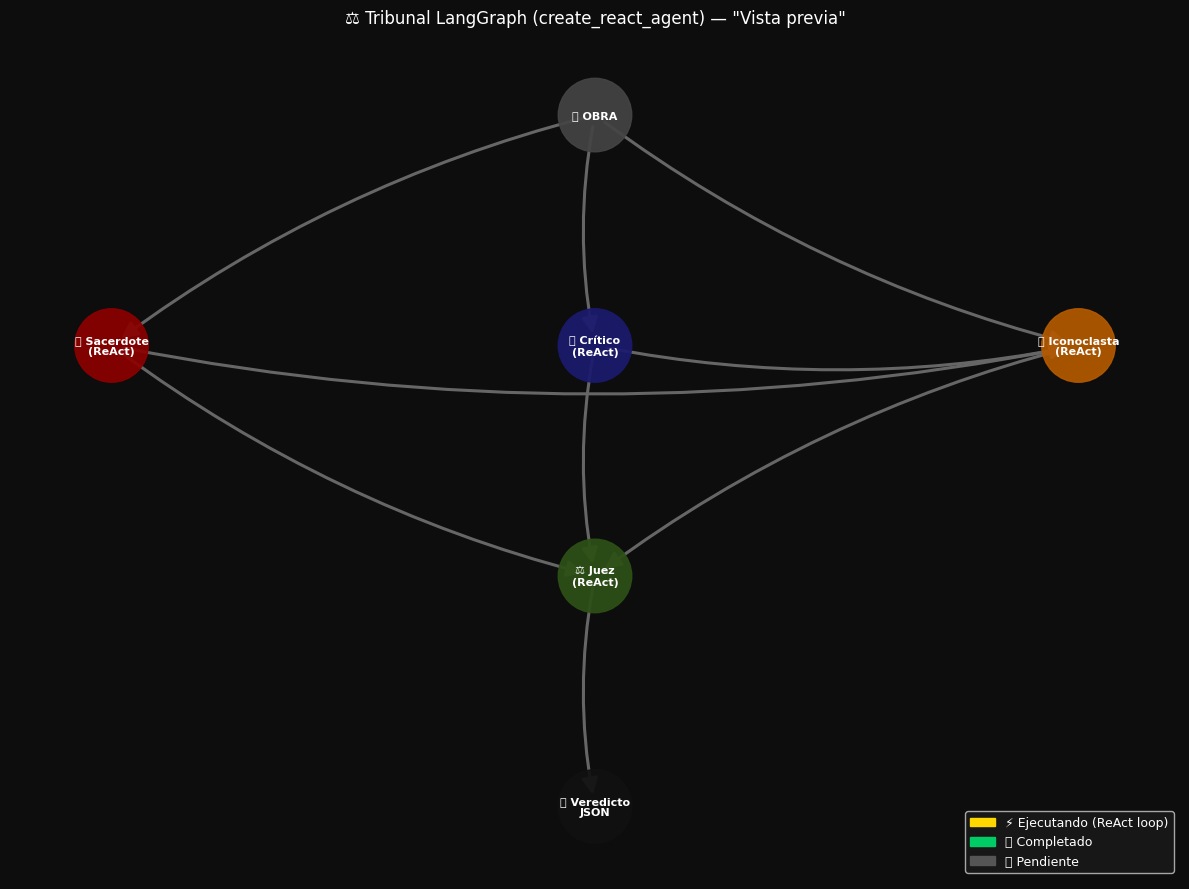

In [8]:
GRAPH_NODES = [
    ('obra',        '📽️ OBRA',           '#444444'),
    ('sacerdote',   '🙏 Sacerdote\n(ReAct)',  '#8B0000'),
    ('critico',     '🎭 Crítico\n(ReAct)',    '#1a1a6e'),
    ('iconoclasta', '🔥 Iconoclasta\n(ReAct)', '#b35900'),
    ('juez',        '⚖️ Juez\n(ReAct)',       '#2d5016'),
    ('veredicto',   '📋 Veredicto\nJSON',     '#111111'),
]
GRAPH_EDGES = [
    ('obra',        'sacerdote'),
    ('obra',        'critico'),
    ('obra',        'iconoclasta'),
    ('sacerdote',   'iconoclasta'),
    ('critico',     'iconoclasta'),
    ('sacerdote',   'juez'),
    ('critico',     'juez'),
    ('iconoclasta', 'juez'),
    ('juez',        'veredicto'),
]
GRAPH_POS = {
    'obra':        ( 0,   3.2),
    'sacerdote':   (-2.4, 1.6),
    'critico':     ( 0,   1.6),
    'iconoclasta': ( 2.4, 1.6),
    'juez':        ( 0,   0),
    'veredicto':   ( 0,  -1.6),
}

def render_graph(title='OBRA', active=None, done=None):
    done = done or []
    G = nx.DiGraph()
    for nid, *_ in GRAPH_NODES: G.add_node(nid)
    G.add_edges_from(GRAPH_EDGES)

    colors, sizes = [], []
    for nid, _, base_color in GRAPH_NODES:
        if nid == active:    colors.append('#FFD700'); sizes.append(3600)
        elif nid in done:    colors.append('#00cc66'); sizes.append(2800)
        else:                colors.append(base_color); sizes.append(2800)

    fig, ax = plt.subplots(figsize=(12, 9))
    ax.set_facecolor('#0d0d0d'); fig.patch.set_facecolor('#0d0d0d')

    nx.draw_networkx_edges(G, GRAPH_POS, ax=ax, edge_color='#666666',
                           arrows=True, arrowsize=24, width=2.2,
                           connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_nodes(G, GRAPH_POS, ax=ax, node_color=colors,
                           node_size=sizes, alpha=0.93)
    labels = {nid: label for nid, label, _ in GRAPH_NODES}
    nx.draw_networkx_labels(G, GRAPH_POS, labels, ax=ax,
                            font_color='white', font_size=8, font_weight='bold')
    legend = [
        mpatches.Patch(color='#FFD700', label='⚡ Ejecutando (ReAct loop)'),
        mpatches.Patch(color='#00cc66', label='✅ Completado'),
        mpatches.Patch(color='#555555', label='⏳ Pendiente'),
    ]
    ax.legend(handles=legend, loc='lower right',
              facecolor='#1a1a1a', labelcolor='white', fontsize=9)
    ax.set_title(f'⚖️ Tribunal LangGraph (create_react_agent) — "{title}"',
                 color='white', fontsize=12, pad=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

render_graph('Vista previa')

## 🖨️ Función de presentación del veredicto

In [9]:
def print_block(emoji, nombre, texto):
    sep = '═' * 66
    print(f'\n{sep}')
    print(f'  {emoji}  {nombre.upper()}')
    print(sep)
    for line in textwrap.wrap(texto, width=64):
        print(f'  {line}')


def print_veredicto(v: dict):
    emojis = {'sacerdote': '🙏', 'critico': '🎭', 'iconoclasta': '🔥'}
    eg = emojis.get(v.get('ganador_id', ''), '🏆')

    print('\n' + '█' * 66)
    print('█' + ' ' * 24 + '⚖️  VEREDICTO FINAL' + ' ' * 22 + '█')
    print('█' * 66)
    print(f'\n  🏆 GANADOR : {eg} {v.get("ganador", "N/A")}')
    print(f'\n  📜 FUNDAMENTO:')
    for line in textwrap.wrap(v.get('fundamento_legal', ''), 62):
        print(f'     {line}')
    print(f'\n  🔨 SENTENCIA: "{v.get("sentencia", "")}"')

    print('\n  📊 PUNTAJES (solidez / coherencia / evidencia):')
    for aid, aemoji in emojis.items():
        p = v.get('puntajes', {}).get(aid, {})
        total = sum(p.values()) if p else 0
        bar = '█' * (total // 3) + '░' * (10 - total // 3)
        print(f'  {aemoji} {aid:<14} {bar}  {total}/30')
        if p:
            print(f'     solidez:{p.get("solidez",0)}  coherencia:{p.get("coherencia",0)}  evidencia:{p.get("evidencia",0)}')

    print('\n  🎯 INCOHERENCIAS MÁS SÓLIDAS:')
    for i, inc in enumerate(v.get('incoherencias_mas_solidas', []), 1):
        for line in textwrap.wrap(f'{i}. {inc}', 62):
            print(f'  {line}')

    print('\n  ❌ FALLOS DE LOS PERDEDORES:')
    for nombre, razon in v.get('fallos_de_los_perdedores', {}).items():
        for line in textwrap.wrap(f'• {nombre}: {razon}', 62):
            print(f'  {line}')

    print('\n' + '█' * 66)

print('✅ Funciones de presentación listas.')

✅ Funciones de presentación listas.


## 🚀 Pipeline principal — invocar el grafo

In [10]:
def run_tribunal(obra: str) -> dict:
    """
    Invoca el StateGraph completo para una obra.
    El grafo ejecuta: sacerdote → critico → iconoclasta → juez
    Cada nodo es un create_react_agent con tools propias.
    """
    print(f'\n⚖️  Iniciando Tribunal LangGraph para: "{obra}"')
    print('─' * 60)

    done = []

    # Estado inicial
    initial_state: TribunalState = {
        'obra': obra,
        'arg_sacerdote': '',
        'arg_critico': '',
        'arg_iconoclasta': '',
        'veredicto_raw': '',
        'veredicto': {},
        'log': [f'Tribunal iniciado para "{obra}"'],
    }

    # Ejecutar el grafo paso a paso con stream para visualización
    final_state = None
    node_order = ['sacerdote', 'critico', 'iconoclasta', 'juez']

    for step in tribunal_graph.stream(initial_state, stream_mode='updates'):
        node_name = list(step.keys())[0]
        done.append(node_name)

        # Renderizar grafo con nodo activo
        next_idx = node_order.index(node_name) + 1 if node_name in node_order else -1
        next_node = node_order[next_idx] if next_idx < len(node_order) else 'veredicto'
        render_graph(obra, active=next_node if node_name != 'juez' else 'veredicto', done=done)

        # Mostrar output del nodo
        node_data = step[node_name]
        emoji_map = {'sacerdote': '🙏', 'critico': '🎭', 'iconoclasta': '🔥', 'juez': '⚖️'}
        name_map  = {'sacerdote': 'El Sacerdote', 'critico': 'El Crítico de Arte',
                     'iconoclasta': 'El Crítico del Crítico', 'juez': 'El Juez'}

        if node_name != 'juez':
            key = f'arg_{node_name}'
            print_block(emoji_map[node_name], name_map[node_name], node_data.get(key, ''))
        else:
            final_state = node_data

    # Mostrar veredicto
    if final_state and 'veredicto' in final_state:
        v = final_state['veredicto'].get('veredicto', final_state['veredicto'])
        if 'error' in v:
            print(f'\n❌ Error en veredicto: {v["error"]}')
            print(f'Raw: {v.get("raw", "")[:300]}')
        else:
            print_veredicto(v)

    # Log de ejecución
    print('\n📋 LOG DE EJECUCIÓN:')
    for entry in initial_state.get('log', []):
        print(f'   {entry}')

    return final_state or {}


print('✅ Pipeline listo.')

✅ Pipeline listo.


## 🎬 ¡Convocar al Tribunal!

🎬📚 ¿Qué obra quieres llevar al tribunal? Police Academy

⚖️  Iniciando Tribunal LangGraph para: "Police Academy"
────────────────────────────────────────────────────────────
  🙏 Sacerdote delibera...


/tmp/ipykernel_818/3781763647.py:62: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_818/3781763647.py:62: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


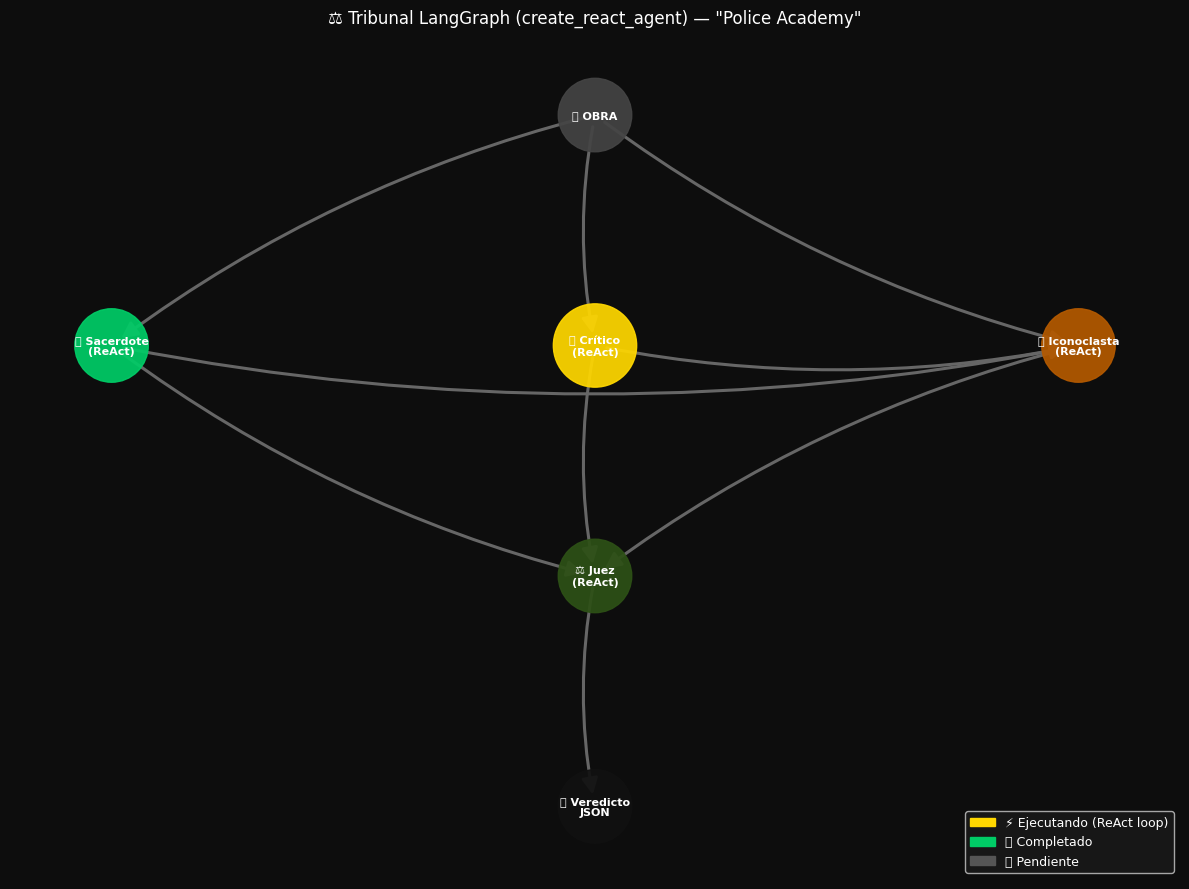


══════════════════════════════════════════════════════════════════
  🙏  EL SACERDOTE
══════════════════════════════════════════════════════════════════
  ¡Por las barbas de los profetas! Esta obra llamada "Police
  Academy" es un monumento a la decadencia moral y una afrenta a
  los principios divinos y naturales que deberían guiar nuestras
  vidas.  Primera incoherencia: ¡Representar a la autoridad
  policial, pilar del orden social, como incompetente y ridícula
  es un sacrilegio contra la organización divina de la sociedad!
  ¿Cómo se atreve esta obra a mofarse de aquellos que deberían ser
  custodios de la moral y la ley? Al hacer esto, siembra la
  semilla de la desconfianza y el caos, lo cual es una abominación
  ante los ojos del Señor (Romanos 13:1).  Segunda incoherencia:
  El uso excesivo de comedia vulgar y situaciones inmorales para
  entretenimiento es una burla al mandamiento de mantener la
  pureza de pensamiento. El humor debe elevar el espíritu, no
  hundirlo en la ch

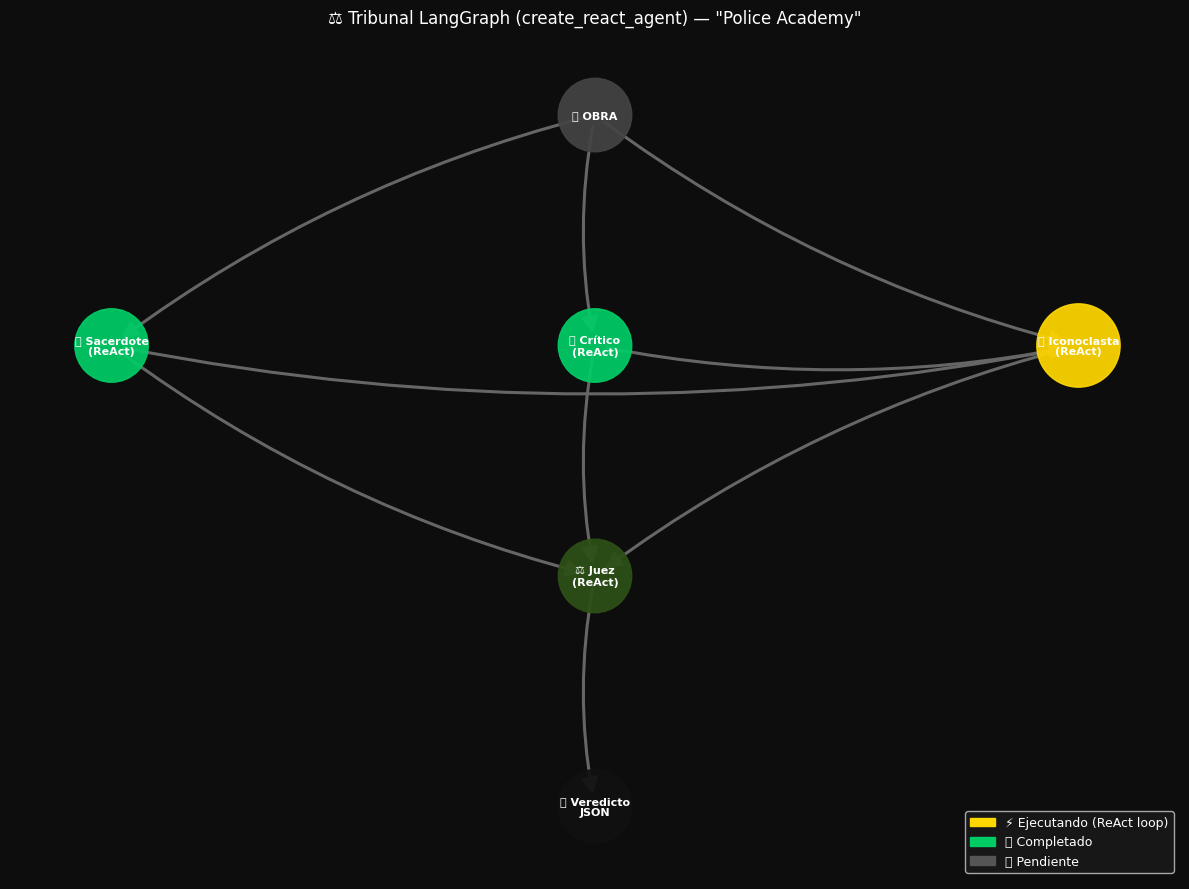


══════════════════════════════════════════════════════════════════
  🎭  EL CRÍTICO DE ARTE
══════════════════════════════════════════════════════════════════
  Ah, "Police Academy", una obra que evoca un sentido de nostalgia
  risible más que una admiración genuina. Comencemos con la
  comedia slapstick, un recurso que ya fue explorado de manera
  sublime por Godard en "À bout de souffle" (1960). En "Police
  Academy", el uso del slapstick se siente como un eco débil, un
  reflejo pálido que oscila entre la redundancia y la banalidad,
  sin atreverse a innovar ni a subvertir las convenciones del
  género.  Pasemos al desarrollo de personajes. Borges, con su
  maestría en "Ficciones", nos mostró que incluso en la brevedad
  hay una profundidad insondable. Sin embargo, "Police Academy"
  presenta personajes unidimensionales, caricaturas que nunca
  trascienden su función de servir a un gag visual o a un chiste
  fácil, careciendo del rigor narrativo que Borges tanto valoraba.
  Finalmen

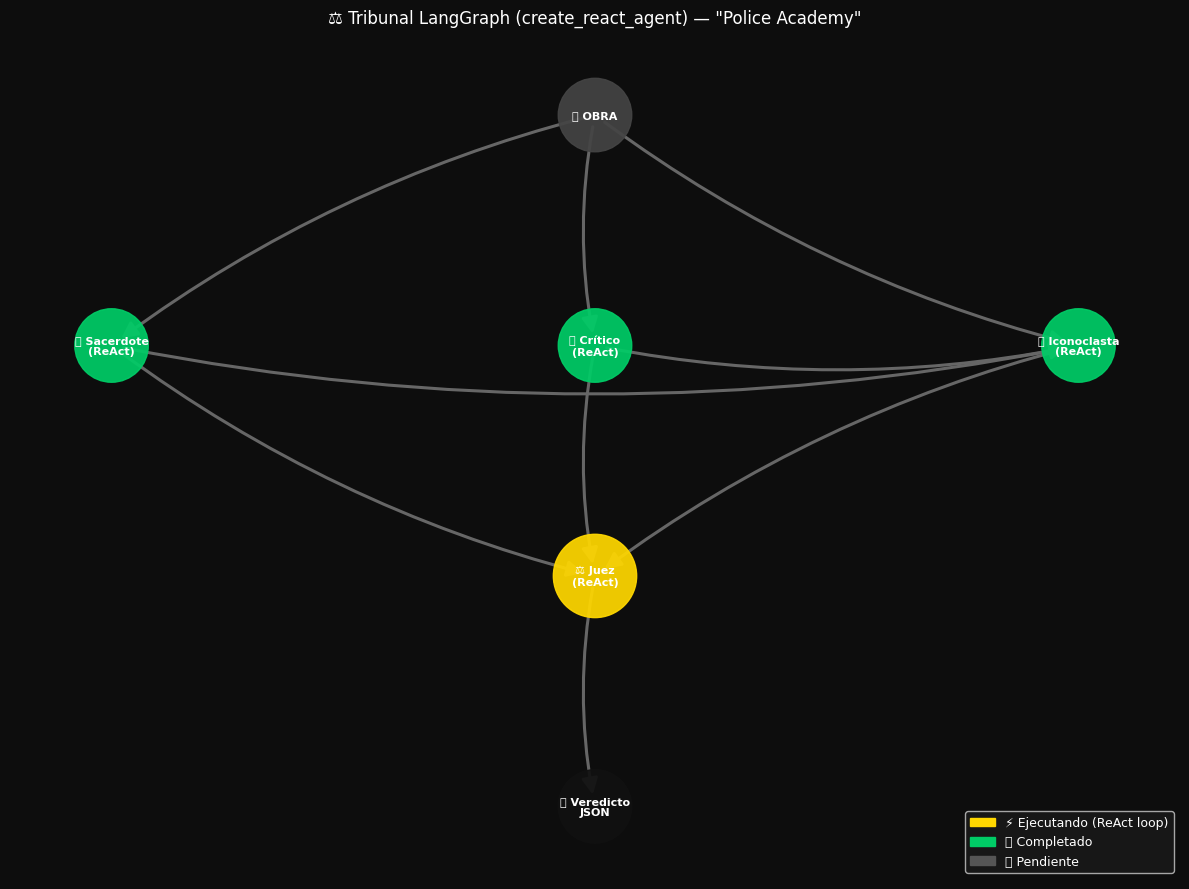


══════════════════════════════════════════════════════════════════
  🔥  EL CRÍTICO DEL CRÍTICO
══════════════════════════════════════════════════════════════════
  Primero, el argumento del sacerdote sobre la "decadencia moral"
  de "Police Academy" al ridiculizar a la policía es una tontería
  total. No nos olvidemos que el humor es una herramienta
  poderosísima para exponer las fallas del poder. Al hacer reír a
  la gente con la incompetencia policial, se expone la hipocresía
  del sistema, algo que el establishment prefiere ocultar.
  ¿Decadencia moral? Más bien, una celebración de la verdad a
  través de la risa.  Luego, el crítico deplora el "eco débil" del
  slapstick en comparación con Godard. Olvida que el propósito de
  "Police Academy" no es competir con el existencialismo francés,
  sino divertir. Lo que critican como "banalidad" es precisamente
  lo que le hace accesible y querida por el público. La comedia no
  siempre necesita ser un intrincado tapiz intelectual; a vece

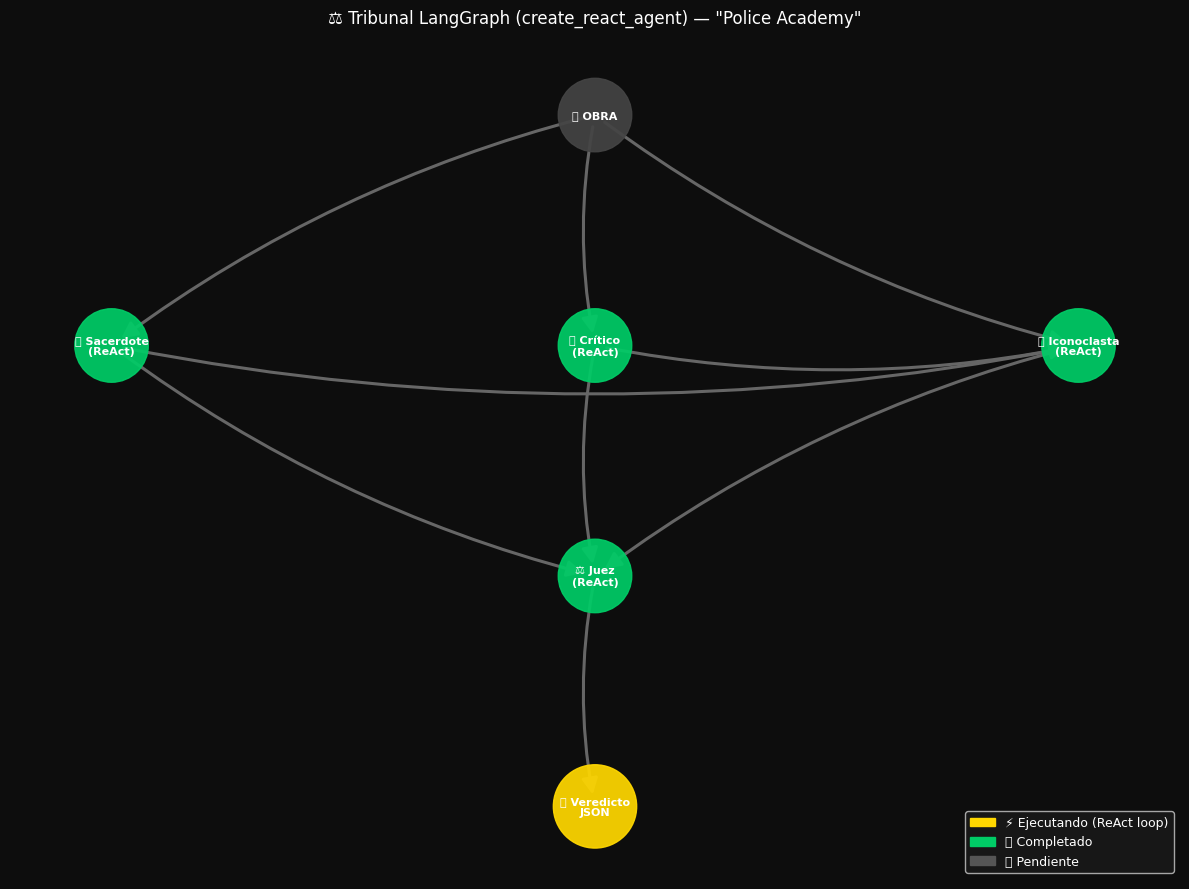


██████████████████████████████████████████████████████████████████
█                        ⚖️  VEREDICTO FINAL                      █
██████████████████████████████████████████████████████████████████

  🏆 GANADOR : 🔥 iconoclasta

  📜 FUNDAMENTO:
     El iconoclasta presenta un argumento sólido y coherente al
     defender el valor del humor en la crítica social, desafiando
     las perspectivas elitistas y moralistas. Aunque carece de
     ejemplos concretos, su enfoque es persuasivo y relevante.

  🔨 SENTENCIA: "El humor revela verdades que el poder prefiere ocultar."

  📊 PUNTAJES (solidez / coherencia / evidencia):
  🙏 sacerdote      █████░░░░░  15/30
     solidez:5  coherencia:6  evidencia:4
  🎭 critico        ██████░░░░  18/30
     solidez:6  coherencia:7  evidencia:5
  🔥 iconoclasta    ███████░░░  22/30
     solidez:8  coherencia:8  evidencia:6

  🎯 INCOHERENCIAS MÁS SÓLIDAS:
  1. El sacerdote no considera otras perspectivas.
  2. El crítico se limita a un marco académico.
  3

In [11]:
obra = input('🎬📚 ¿Qué obra quieres llevar al tribunal? ')

if obra.strip():
    resultado = run_tribunal(obra.strip())
else:
    print('⚠️ Debes ingresar una obra válida.')

## 📋 JSON completo del veredicto

In [12]:
try:
    v = resultado.get('veredicto', {})
    print(json.dumps(v, ensure_ascii=False, indent=2))
except Exception:
    print('⚠️ Primero ejecuta la celda anterior.')

{
  "veredicto": {
    "ganador": "iconoclasta",
    "ganador_id": "iconoclasta",
    "puntajes": {
      "sacerdote": {
        "solidez": 5,
        "coherencia": 6,
        "evidencia": 4
      },
      "critico": {
        "solidez": 6,
        "coherencia": 7,
        "evidencia": 5
      },
      "iconoclasta": {
        "solidez": 8,
        "coherencia": 8,
        "evidencia": 6
      }
    },
    "fundamento_legal": "El iconoclasta presenta un argumento sólido y coherente al defender el valor del humor en la crítica social, desafiando las perspectivas elitistas y moralistas. Aunque carece de ejemplos concretos, su enfoque es persuasivo y relevante.",
    "fallos_de_los_perdedores": {
      "perdedor1": "El sacerdote se basa en principios morales sin un análisis crítico de la obra.",
      "perdedor2": "El crítico ofrece un análisis elitista sin ejemplos específicos de la obra."
    },
    "incoherencias_mas_solidas": [
      "El sacerdote no considera otras perspectivas.",
  

## 🔍 Inspeccionar el grafo compilado

In [13]:
# LangGraph expone el grafo como imagen Mermaid
print('📊 Estructura del StateGraph (LangGraph):')
print(tribunal_graph.get_graph().draw_mermaid())

📊 Estructura del StateGraph (LangGraph):
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	sacerdote(sacerdote)
	critico(critico)
	iconoclasta(iconoclasta)
	juez(juez)
	__end__([<p>__end__</p>]):::last
	__start__ --> sacerdote;
	critico --> iconoclasta;
	iconoclasta --> juez;
	sacerdote --> critico;
	juez --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 🔄 Modo sesión: múltiples obras

In [ ]:
historial = []
print("⚖️ Sesión abierta. Escribe 'salir' para cerrar.\n")

while True:
    obra = input('\n➤ Obra a juzgar (o "salir"): ').strip()
    if obra.lower() in ('salir', 'exit', 'quit', ''):
        print(f'\n🔨 Sesión cerrada. Obras juzgadas: {len(historial)}')
        break
    try:
        r = run_tribunal(obra)
        historial.append({'obra': obra, 'resultado': r})
    except Exception as e:
        print(f'❌ Error: {e}')